# COGS 108 - EDA Checkpoint

## Authors

- Mia Mayer: Conceptualization, Project administration, Writing – review & editing
- Julia Visaya: Data curation, Software, Writing – review & editing
- Hemi Kim: Analysis, Data curation, Software, Visualization, Writing – original draft
- Katelyn Ma: Background research, Writing – review & editing
- Catherine Do: Background research, Writing – original draft

# Research Question

Is there a statistically significant association between institutional funding levels at U.S. public colleges and the median annual earnings of graduates approximately ten years after enrollment?

Funding will be measured using institution-level financial variables such as total revenue, instructional expenditures, and state and federal appropriations obtained from IPEDS/NCES. Graduate outcomes will be measured using the College Scorecard median earnings metric at approximately ten years after completion.

To account for potential confounding factors, we will include controls for institutional scale (enrollment and completions), geographic variation (state/region), and regional cost-of-living proxies (ACS median household income). This is a statistical inference project using correlation and regression analyses.

## Background and Prior Work

Public higher education funding plays a central role in discussions about economic mobility and workforce outcomes in the United States. Public colleges and universities educate a substantial portion of the nation’s working population and receive funding from a combination of state appropriations, federal support, and tuition revenue.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) However, funding levels vary significantly across states and institutions due to differences in state budgets, enrollment patterns, and regional economic priorities.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) These disparities raise an important question: does greater institutional investment translate into stronger long-term economic outcomes for graduates?

To investigate this relationship, we draw on publicly available administrative datasets from the National Center for Education Statistics (NCES), IPEDS, and the U.S. Department of Education’s College Scorecard. These sources provide institution-level data on funding, enrollment, completions, tuition, and graduate earnings.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) In particular, College Scorecard includes median earnings metrics approximately ten years after enrollment, allowing us to examine long-term labor market outcomes.<a name="cite_ref-6"></a>[<sup>6</sup>](#cite_note-6)

A key challenge when comparing earnings across institutions is geographic variation in labor markets and cost of living. Similar nominal salaries may imply different standards of living depending on regional economic conditions. To address this, we incorporate regional socioeconomic context using American Community Survey (ACS) data, including median household income as a cost-of-living proxy.<a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4) Including these controls helps reduce omitted variable bias when estimating the association between funding and earnings.

This project also builds on prior education-focused data science analyses. A previous COGS 108 project, *Are Universities Worth the Opportunity Cost?*, examined institutional-level education and earnings outcomes using similar federal datasets.<a name="cite_ref-5"></a>[<sup>5</sup>](#cite_note-5) That work provides a methodological foundation for linking institutional characteristics to measurable labor market outcomes, which we extend by focusing specifically on institutional funding as a predictor of long-term graduate earnings.

---

### References

1. <a name="cite_note-1"></a>[^](#cite_ref-1) National Center for Education Statistics (NCES). *Digest of Education Statistics*. https://nces.ed.gov/programs/digest/
2. <a name="cite_note-2"></a>[^](#cite_ref-2) NCES Condition of Education — Postsecondary Institution Revenue. https://nces.ed.gov/programs/coe/indicator/cud/postsecondary-institution-revenue
3. <a name="cite_note-3"></a>[^](#cite_ref-3) Integrated Postsecondary Education Data System (IPEDS). https://nces.ed.gov/ipeds/
4. <a name="cite_note-4"></a>[^](#cite_ref-4) U.S. Census Bureau — American Community Survey (ACS) Table B19013. https://data.census.gov/
5. <a name="cite_note-5"></a>[^](#cite_ref-5) COGS 108 Final Project (Sp17): *Are Universities Worth the Opportunity Cost?* https://github.com/COGS108/FinalProjects-Sp17/blob/master/081-FinalProject.ipynb
6. <a name="cite_note-6"></a>[^](#cite_ref-6) College Scorecard — Data Documentation and Bulk Downloads. https://collegescorecard.ed.gov/data/

# Hypothesis

We hypothesize that higher levels of institutional funding at public colleges are positively associated with higher median earnings approximately ten years after enrollment.

Specifically, we predict that instructional expenditures per student and total revenue per student will show a statistically significant positive correlation with long-term graduate earnings. We expect this relationship to remain significant even after controlling for institutional scale, geographic variation, and regional socioeconomic factors.

Our reasoning is that greater institutional funding may support smaller student-to-faculty ratios, improved academic resources, expanded career services, and stronger industry connections, all of which may enhance students’ human capital and labor market outcomes.

## Data

### Data Overview

Our project uses publicly available administrative datasets from the National Center for Education Statistics (NCES), the Integrated Postsecondary Education Data System (IPEDS), and the U.S. Department of Education College Scorecard.

This project integrates three federal administrative data sources:

1. IPEDS (NCES) for institutional finance and enrollment data.
2. U.S. Department of Education College Scorecard for graduate earnings and geographic identifiers.
3. U.S. Census Bureau American Community Survey (ACS) for state-level median household income as a cost-of-living proxy.

These datasets were merged using institutional identifiers (`UNITID`) and state postal abbreviations (`STABBR`).

In [135]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("./modules")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Dataset #1: IPEDS Institutional Finance Data (2012)

This dataset contains institution-level financial and enrollment data for U.S. public colleges and universities obtained from the Integrated Postsecondary Education Data System (IPEDS), maintained by the National Center for Education Statistics (NCES).

The unit of observation is the institution, identified by `UNITID`.

Key variables used in this project include:

- `instruction_exp_2012`: Total instructional expenditures in U.S. dollars. This includes faculty salaries, instructional support, and other direct instructional costs.
- `enrollment_2012`: Total student enrollment.
- `funding_per_student_2012`: Instructional expenditures divided by enrollment, representing per-student instructional spending.

Instructional expenditures were converted to per-student funding to account for institutional size differences, as larger institutions naturally have higher total expenditures.

Potential concerns include variation in institutional accounting practices and the fact that instructional expenditures do not capture all revenue sources (e.g., endowments or private donations).

In [136]:
import pandas as pd

# Dataset #1 (processed; created in Data Checkpoint)
df_base = pd.read_csv("data/02-processed/merged_ipeds2012_scorecard2012_13.csv")

ipeds_subset = df_base[[
    "UNITID",
    "instruction_exp_2012",
    "enrollment_2012",
    "funding_per_student_2012"
]].copy()

ipeds_subset.head()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012
0,138558,10812772.0,3233.0,3344.501083
1,126182,20371768.0,3290.0,6192.026748
2,100654,37967292.0,4853.0,7823.468370
3,100724,42848156.0,5816.0,7367.289546
4,138716,28153311.0,4275.0,6585.569825


In [137]:
ipeds_subset.shape

(636, 4)

In [155]:
ipeds_subset.isna().sum()

UNITID                      0
instruction_exp_2012        0
enrollment_2012             0
funding_per_student_2012    0
dtype: int64

In [156]:
ipeds_subset.describe()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012
count,636.000000,6.360000e+02,636.000000,636.000000
mean,183637.044025,1.070996e+08,12301.767296,9329.452891
std,49891.754087,1.523262e+08,11588.545259,14888.693575
min,100654.000000,0.000000e+00,205.000000,0.000000
25%,148434.500000,2.243064e+07,3767.500000,5009.187282
50%,184955.500000,5.411952e+07,8293.000000,6399.944574
75%,216219.500000,1.217680e+08,16994.250000,8645.596036
max,451671.000000,1.450832e+09,73378.000000,253742.803630


The IPEDS funding variables exhibit substantial right skew. While the median instructional funding per student is approximately $6,400, the maximum exceeds $250,000, suggesting the presence of extreme outliers. This skew motivates the use of log transformations in later analyses.

### Dataset #2: College Scorecard Earnings Data

This dataset contains institution-level student outcome metrics from the U.S. Department of Education College Scorecard. The unit of observation is the institution, identified by `UNITID`.

Key variable used:
- `MD_EARN_WNE_P10`: Median annual earnings (USD) approximately 10 years after enrollment.

This variable represents the median earnings of former students who received federal financial aid, measured roughly ten years after entering the institution. Earnings values were previously cleaned and converted to numeric format during the data processing stage.

After merging with IPEDS financial data, the dataset contains 636 institutions.

The College Scorecard dataset also provides institutional geographic identifiers, including state postal abbreviation (`STABBR`) and Census region code (`REGION`), which are used for geographic controls in subsequent analyses.

#### Earnings

In [157]:
scorecard_subset = df_base[[
    "UNITID",
    "MD_EARN_WNE_P10"
]].copy()

scorecard_subset.head(), scorecard_subset.shape

(   UNITID  MD_EARN_WNE_P10
 0  138558          32000.0
 1  126182          32800.0
 2  100654          30300.0
 3  100724          26600.0
 4  138716          31500.0,
 (636, 2))

In [158]:
scorecard_subset.isna().sum()

UNITID             0
MD_EARN_WNE_P10    0
dtype: int64

In [159]:
scorecard_subset.describe()

,UNITID,MD_EARN_WNE_P10
count,636.000000,636.000000
mean,183637.044025,41747.327044
std,49891.754087,17210.897731
min,100654.000000,17200.000000
25%,148434.500000,34100.000000
50%,184955.500000,39000.000000
75%,216219.500000,44425.000000
max,451671.000000,219900.000000


Graduate earnings exhibit moderate right skew. The median earnings value is approximately $39,000, while the maximum exceeds $219,000, indicating that a small number of institutions report substantially higher earnings outcomes. This skew further motivates the use of log transformations when modeling the relationship between institutional funding and graduate earnings.

#### Geographic identifiers

In [160]:
import scorecard_geo

geo_df = scorecard_geo.extract_geo("data/00-raw/MERGED2012_13_PP.csv")
geo_df.head()

,UNITID,STABBR,REGION
0,100636,AL,0
1,100654,AL,5
2,100663,AL,5
3,100690,AL,5
4,100706,AL,5


In [161]:
geo_df.shape

(7862, 3)

The full College Scorecard dataset contains 7,862 institutions. Only a subset of these institutions appear in our analytic dataset because our analysis focuses on public institutions with complete funding and earnings data.

In [162]:
geo_df.to_csv("data/02-processed/scorecard_geo.csv", index=False)

### Dataset #3: American Community Survey (ACS) Median Household Income (2012)

This dataset contains state-level median household income estimates from the U.S. Census Bureau’s American Community Survey (ACS) 5-Year Estimates (2012).

The unit of observation is the state.

Key variable used:
- `median_household_income`: Median household income (USD) for each U.S. state and the District of Columbia.

The dataset was downloaded directly from data.census.gov (Table B19013: Median Household Income in the Past 12 Months) and converted from wide format to long format. State names were mapped to standard postal abbreviations (STABBR) to align with the College Scorecard dataset.

Territories not included in the ACS state table (AS, MP, GU, VI) were excluded from analyses requiring this cost-of-living proxy.

In [163]:
import acs_processing

acs_clean = acs_processing.build_income_long("data/00-raw/acs_median_income_2012.csv")
acs_clean.head()

,STABBR,median_household_income
0,AL,41574.0
1,AK,67712.0
2,AZ,47826.0
3,AR,40112.0
4,CA,58328.0


In [164]:
acs_clean.shape

(52, 2)

In [165]:
acs_clean.to_csv("data/02-processed/acs_processing.csv", index=False)

The ACS dataset contains 52 observations corresponding to the 50 U.S. states, the District of Columbia, and Puerto Rico. This dataset will be merged with institutional data using the state postal abbreviation (STABBR) as a geographic cost-of-living proxy.

### Data Merging and Final Analytic Dataset

IPEDS institutional finance and enrollment data were merged with College Scorecard earnings data using the shared institutional identifier `UNITID`.

Institutions missing key variables (funding per student or median earnings) were excluded. A reporting artifact in which one institution recorded zero instructional expenditures was also removed prior to log-transformed analysis.

State-level median household income from the 2012 ACS 5-Year Estimates was merged using state postal abbreviations (`STABBR`). Institutions located in U.S. territories not included in the ACS state table (AS, MP, GU, VI) were excluded from analyses requiring the cost-of-living proxy.

The final analytic dataset used for multivariate modeling contains 631 institutions and includes the following primary variables:

- `funding_per_student_2012`
- `MD_EARN_WNE_P10`
- `enrollment_2012`
- `median_household_income`
- `REGION`
- log-transformed funding and earnings variables

In [169]:
import pandas as pd
import numpy as np

df_base = pd.read_csv("data/02-processed/merged_ipeds2012_scorecard2012_13.csv")
geo_df = pd.read_csv("data/02-processed/scorecard_geo.csv")
acs_clean = pd.read_csv("data/02-processed/acs_processing.csv")

df_base.shape, geo_df.shape, acs_clean.shape

((636, 5), (7862, 3), (52, 2))

In [170]:
df = df_base.merge(geo_df, on="UNITID", how="left")

df.head()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10,STABBR,REGION
0,138558,10812772.0,3233.0,3344.501083,32000.0,GA,5
1,126182,20371768.0,3290.0,6192.026748,32800.0,CO,7
2,100654,37967292.0,4853.0,7823.468370,30300.0,AL,5
3,100724,42848156.0,5816.0,7367.289546,26600.0,AL,5
4,138716,28153311.0,4275.0,6585.569825,31500.0,GA,5


In [171]:
df = df.merge(acs_clean, on="STABBR", how="left")

df.head()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10,STABBR,REGION,median_household_income
0,138558,10812772.0,3233.0,3344.501083,32000.0,GA,5,47209.0
1,126182,20371768.0,3290.0,6192.026748,32800.0,CO,7,56765.0
2,100654,37967292.0,4853.0,7823.468370,30300.0,AL,5,41574.0
3,100724,42848156.0,5816.0,7367.289546,26600.0,AL,5,41574.0
4,138716,28153311.0,4275.0,6585.569825,31500.0,GA,5,47209.0


In [172]:
df = df.dropna(subset=["median_household_income"]).copy()

df.shape

(632, 8)

In [173]:
df = df[df["funding_per_student_2012"] > 0].copy()

df.shape

(631, 8)

In [175]:
df["log_funding"] = np.log(df["funding_per_student_2012"])
df["log_earnings"] = np.log(df["MD_EARN_WNE_P10"])

df.shape

(631, 10)

In [176]:
df.head()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012,MD_EARN_WNE_P10,STABBR,REGION,median_household_income,log_funding,log_earnings
0,138558,10812772.0,3233.0,3344.501083,32000.0,GA,5,47209.0,8.115073,10.373491
1,126182,20371768.0,3290.0,6192.026748,32800.0,CO,7,56765.0,8.731018,10.398184
2,100654,37967292.0,4853.0,7823.468370,30300.0,AL,5,41574.0,8.964883,10.318903
3,100724,42848156.0,5816.0,7367.289546,26600.0,AL,5,41574.0,8.904805,10.188666
4,138716,28153311.0,4275.0,6585.569825,31500.0,GA,5,47209.0,8.792636,10.357743


After merging the three datasets and removing institutions with missing geographic information or reporting artifacts, the final analytic dataset contains 631 institutions and 10 variables used in subsequent exploratory and regression analyses.

## Results

### Exploratory Data Analysis

All exploratory analyses below use the final analytic dataset (df_acs, n=631) constructed in the Data section, which excludes institutions missing ACS income data and removes a single zero-funding reporting artifact prior to log transformation.

#### Funding vs. Earnings

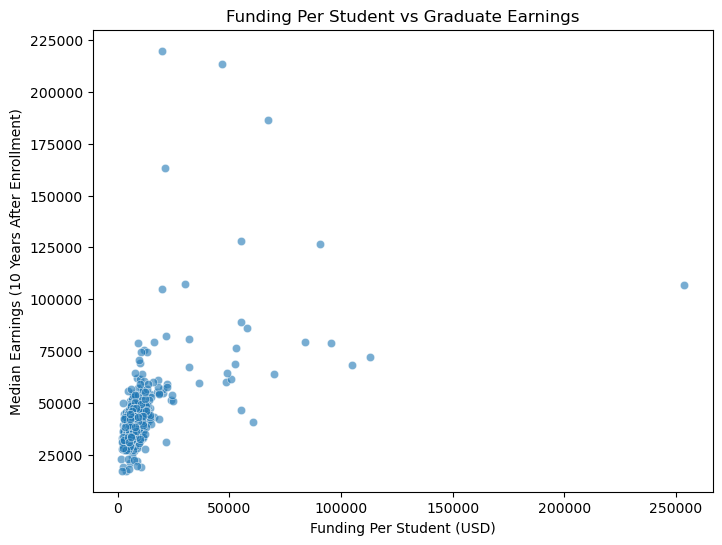

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="funding_per_student_2012",
    y="MD_EARN_WNE_P10",
    data=df_acs,
    alpha=0.6
)

plt.xlabel("Funding Per Student (USD)")
plt.ylabel("Median Earnings (10 Years After Enrollment)")
plt.title("Funding Per Student vs Graduate Earnings")
plt.show()

The scatterplot suggests a positive association between institutional funding per student and median graduate earnings. However, the distribution of funding values is highly skewed, with a small number of institutions reporting substantially higher spending levels.

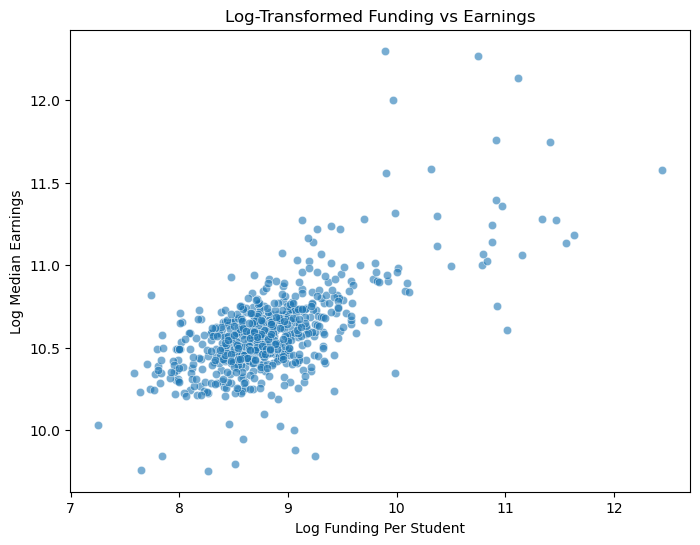

In [82]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="log_funding",
    y="log_earnings",
    data=df_acs,
    alpha=0.6
)

plt.xlabel("Log Funding Per Student")
plt.ylabel("Log Median Earnings")
plt.title("Log-Transformed Funding vs Earnings")
plt.show()

After applying a log transformation to both funding and earnings, the relationship appears more approximately linear. The transformation reduces the influence of extreme outliers and compresses the scale of highly skewed funding values, revealing a clearer positive relationship between institutional funding and graduate earnings.

#### Correlation

In [83]:
raw_corr = df_acs["funding_per_student_2012"].corr(df_acs["MD_EARN_WNE_P10"])
log_corr = df_acs["log_funding"].corr(df_acs["log_earnings"])

raw_corr, log_corr

(np.float64(0.5209970398045101), np.float64(0.6671573563803771))

The Pearson correlation between funding per student and graduate earnings is approximately 0.52 in raw values and increases to about 0.67 after log transformation. The stronger correlation in log space indicates that skewness in the original variables partially obscured the underlying linear relationship.

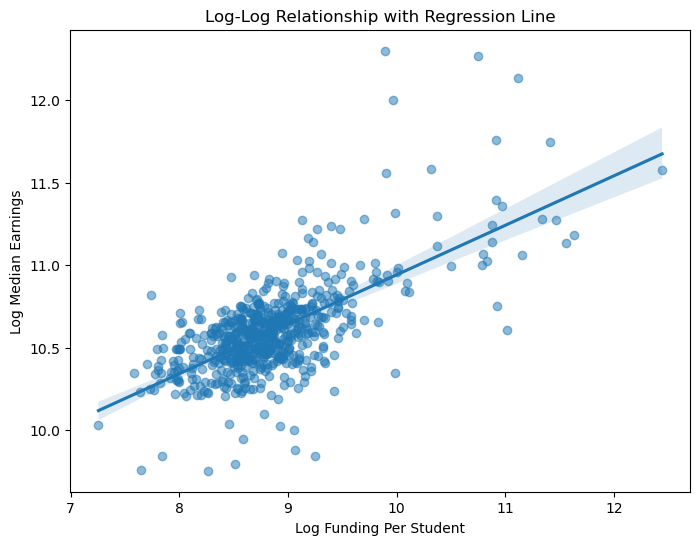

In [84]:
plt.figure(figsize=(8,6))
sns.regplot(
    x="log_funding",
    y="log_earnings",
    data=df_acs,
    scatter_kws={"alpha":0.5}
)

plt.xlabel("Log Funding Per Student")
plt.ylabel("Log Median Earnings")
plt.title("Log-Log Relationship with Regression Line")
plt.show()

The regression line confirms a positive association between institutional funding per student and median graduate earnings. The approximately linear pattern in log-transformed variables supports the use of a log-log regression model in subsequent statistical analysis.

#### Enrollment Check

In [85]:
enroll_earn_corr = df_acs["enrollment_2012"].corr(df_acs["MD_EARN_WNE_P10"])
enroll_fund_corr = df_acs["enrollment_2012"].corr(df_acs["funding_per_student_2012"])

enroll_earn_corr, enroll_fund_corr

(np.float64(0.05964330934535942), np.float64(-0.04520175822293274))

Institutional enrollment shows little correlation with either funding per student or graduate earnings. The correlation between enrollment and earnings is approximately 0.06, while the correlation between enrollment and funding per student is approximately −0.04. These near-zero values suggest that institutional size is unlikely to be a major confounding factor.

#### Correlation Matrix

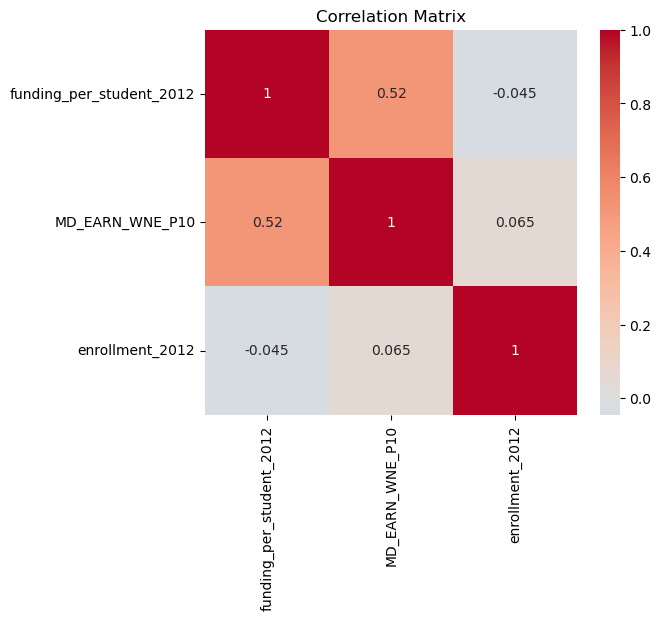

In [86]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[["funding_per_student_2012",
        "MD_EARN_WNE_P10",
        "enrollment_2012"]].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Ethics 

### A. Data Collection
 - [X] **A.1 Informed consent**: Our project uses publicly available datasets collected by federal agencies. Since we have no direct interaction with human subjects, informed consent was handled by the original institutions under their legal and ethical frameworks.
 - [X] **A.2 Collection bias**: There may be collection bias due to how different institutions/districts report funding and how earnings are aggregated geographically. Missing or incomplete records may systematically differ from institutions with complete data. We will document missingness and interpret results cautiously.
 - [X] **A.3 Limit PII exposure**: No personally identifiable information (PII) is used in this project. All data are aggregated at the institution or regional level, preventing identification of individuals.
 - [X] **A.4 Downstream bias mitigation**: When available, variables such as race/ethnicity and gender distributions (or related composition measures) will be included to explore potential disparities in outcomes.

### B. Data Storage
 - [X] **B.1 Data security**: We rely on publicly available data sources and will avoid downloading unnecessary or sensitive data. We will keep dependencies up to date and store data in the repository only as needed for analysis.
 - [X] **B.2 Right to be forgotten**: Not applicable because we do not use PII and use only aggregated public data.
 - [X] **B.3 Data retention plan**: Not applicable because we do not store PII; we will retain only project-relevant, public, aggregated datasets.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Our datasets will not fully capture contextual factors such as local job opportunities, accessibility barriers, or other community support systems. We will acknowledge these limitations in our discussion.
 - [X] **C.2 Dataset bias**: We will explicitly state that correlations may reflect broader socioeconomic forces rather than a direct causal effect of institutional funding.
 - [X] **C.3 Honest representation**: We will present visualizations and summaries that reflect the underlying data accurately and avoid misleading scales or selective reporting.
 - [X] **C.4 Privacy in analysis**: We will not use or display PII, and will only analyze aggregated measures.
 - [X] **C.5 Auditability**: Our analysis will be reproducible and documented in the notebook with clear steps for data cleaning, merging, and modeling.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: We will avoid using protected attributes directly. Our models use institution-level funding rather than individual characteristics, and we include regional controls to reduce geographic variables acting as proxies for wealth demographics.
 - [X] **D.2 Fairness across groups**: We will evaluate whether model errors or residuals differ systematically across institution types (e.g., region, size), to ensure results do not consistently over- or under-estimate outcomes for particular groups of schools.
 - [X] **D.3 Metric selection**: In addition to standard model fit metrics, we will examine error distributions and uncertainty to ensure results are not misleading.
 - [X] **D.4 Explainability**: We will explain results in understandable terms (e.g., how funding and controls relate to predicted earnings) and highlight uncertainty and assumptions.
 - [X] **D.5 Communicate limitations**: We will communicate limitations in plain language, emphasizing that findings are correlational and context-dependent.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: If we extend the project, we would check model stability with updated data releases and re-evaluate assumptions.
 - [X] **E.2 Redress**: If results could plausibly contribute to harm or misinterpretation, we will revise analysis framing and clarify limitations and responsible interpretation.
 - [X] **E.3 Roll back**: Since this is an academic analysis (not a deployed system), results can be revised or withdrawn if issues are found.
 - [X] **E.4 Unintended use**: Our findings could be misused to oversimplify debates about school funding (e.g., implying low-earning outcomes justify budget cuts). We will emphasize that results are correlational and that many unmeasured factors influence earnings beyond what we analyze.


## Team Expectations 

1. **Weekly Sync:** We aim to check in with each other through iMessage every other day while meeting in person at least once a week, transitioning to Zoom if we feel additional meeting days will be beneficial to our group progress. We expect responses to messages within 24 hours, while indicating “urgent” for urgent issues.
2. **Communication Policies:** All communication will be direct and polite. Team members will listen actively to each other, assume good intentions, and encourage everyone to participate equally in discussions. To personally suggest something, a group member should send a message like: “I think X may not work because of Y” or “I think we may need to change X to Y because of Z.”
3. **Conflict Resolution:** We plan to use majority vote for most decisions. For minor decisions such as task assignments, we believe it is more straightforward to assign authority to designated members. If a decision is time-sensitive, we will proceed with the input of responsive teammates and inform any non-responsive teammates afterward.
4. **When a member is struggling:** If a team member is struggling to complete a task, they should notify the group as soon as possible (ideally via iMessage) within 24–28 hours explaining the task and the issue. The team will assess the situation and provide guidance/resources or help break the task into smaller parts. If needed, remaining work will be redistributed to meet deadlines while keeping workload balanced. If unresolved, the team will escalate the issue to a TA or the professor.


## Project Timeline Proposal

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|---|---:|---|---|
| 2/1 | 2:00 PM | Read and review COGS 108 expectations; brainstorm potential topics and research questions | Decide on primary form of communication; finalize project topic; discuss initial hypothesis; begin background research |
| 2/3 | 2:00 PM | Conduct background research on the chosen topic | Identify ideal datasets (NCES, Census); discuss ethics considerations; draft initial project proposal |
| 2/4 | 2:00 PM | Edit, finalize, and submit the project proposal | Confirm dataset choices; discuss data wrangling strategy and analytical approaches; assign group leads |
| 2/14 | 2:00 PM | Import, merge, and format datasets; complete initial data cleaning | Review data wrangling progress; address data issues; plan remaining cleaning steps |
| 2/18 | No meeting (Checkpoint) | Checkpoint #1: Data — finalize datasets and complete initial cleaning | N/A |
| 2/23 | 2:00 PM | Finalize cleaned datasets; begin exploratory analysis | Review early EDA results; refine analysis plan; prepare for EDA checkpoint |
| 3/4 | No meeting (Checkpoint) | Checkpoint #2: EDA — complete EDA and generate initial visualizations | N/A |
| 3/13 | 2:00 PM | Complete statistical analysis; draft results and discussion sections | Review and edit full project draft; plan final revisions |
| 3/18 | Before 11:59 PM | Final Submission — Jupyter Notebook and 3–5 minute video | N/A |